                 Global_Sales
Year_of_Release              
1980-01-01              11.38
1981-01-01              35.77
1982-01-01              28.86
1983-01-01              16.79
1984-01-01              50.36


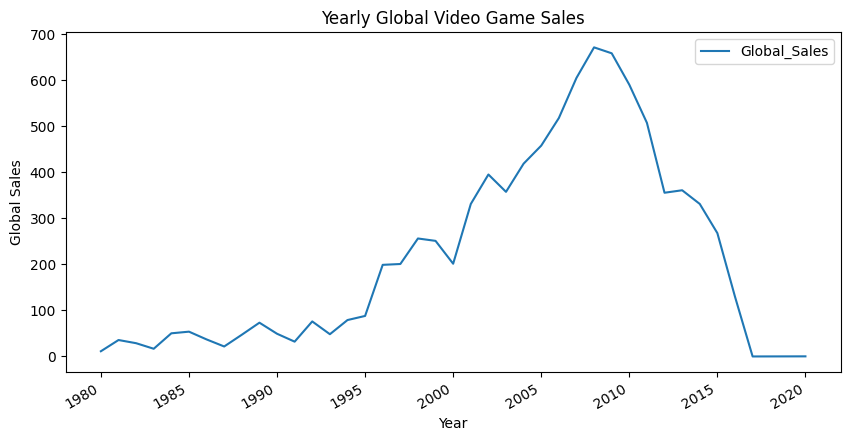

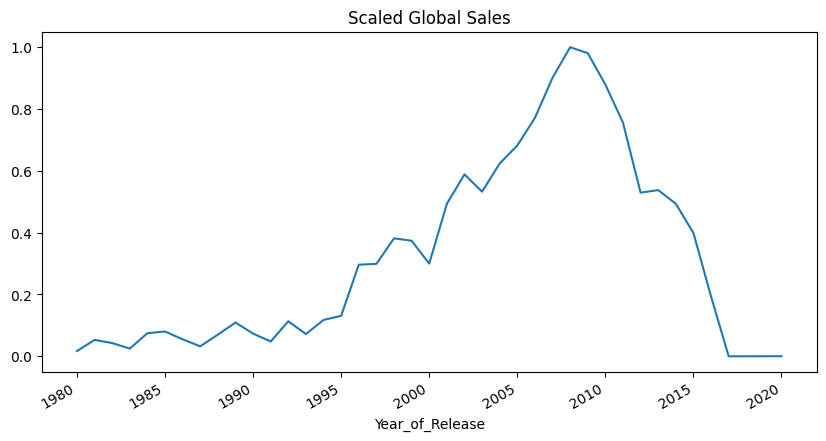

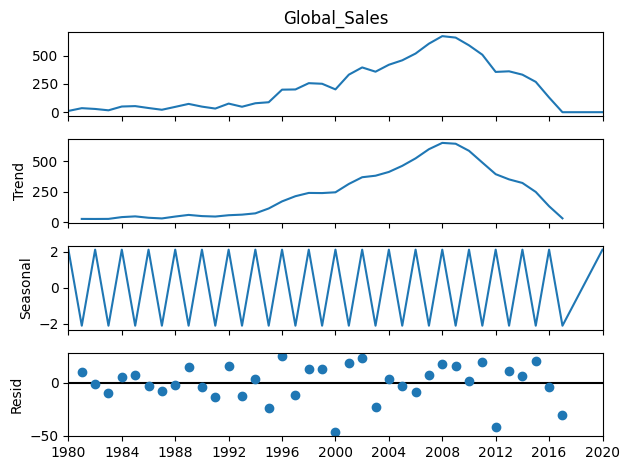

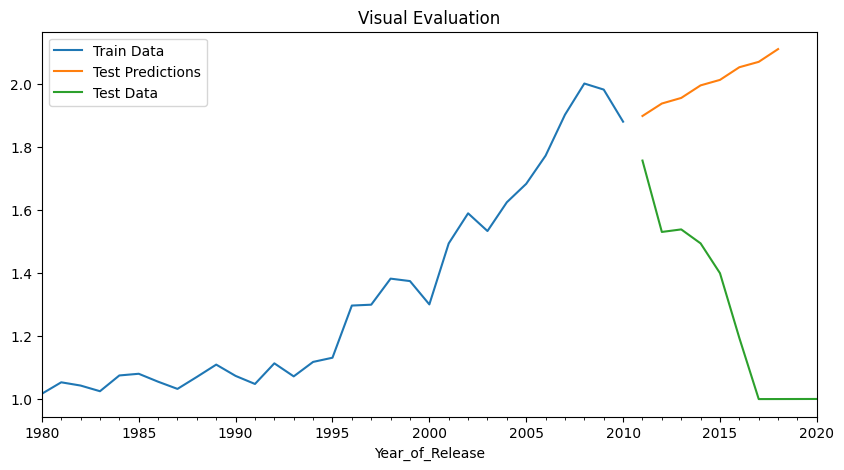

RMSE : 0.7152721472460146


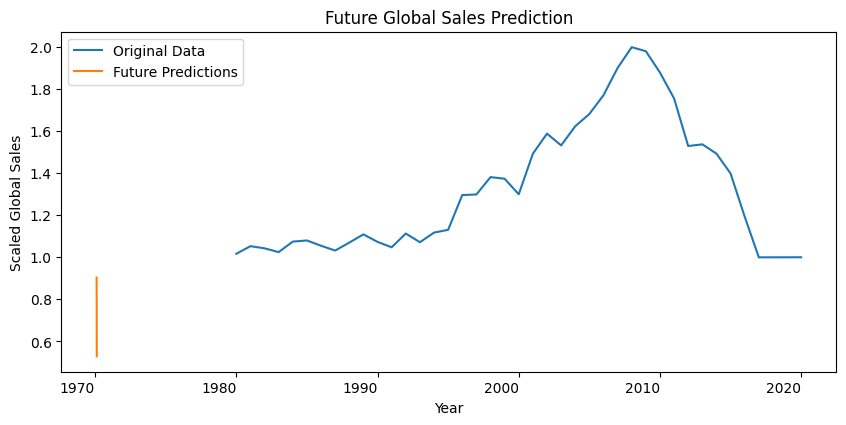

39    0.903692
40    0.812568
41    0.716489
42    0.624793
43    0.529287
dtype: float64


In [2]:
# Import necessary modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import warnings

# Ignore warnings
warnings.filterwarnings("ignore")

# Step 1: Load the dataset
data = pd.read_csv('Video_Games_Sales.csv')

# Clean column names
data.columns = data.columns.str.strip()

# Convert year column to datetime
data['Year_of_Release'] = pd.to_datetime(
    data['Year_of_Release'],
    format='%Y',
    errors='coerce'
)

# Remove missing values
data = data.dropna(subset=['Year_of_Release', 'Global_Sales'])

# Set year as index
data.set_index('Year_of_Release', inplace=True)

# Step 2: Select target column
data = data[['Global_Sales']]

# Step 3: Aggregate yearly sales
data_yearly = data.groupby(data.index).sum()

# Display yearly data
print(data_yearly.head())

# Step 4: Plot original yearly data
data_yearly.plot(figsize=(10,5))

plt.title("Yearly Global Video Game Sales")
plt.ylabel("Global Sales")
plt.xlabel("Year")

plt.show()

# Step 5: Scale the data
scaler = MinMaxScaler()

scaled_data = pd.Series(
    scaler.fit_transform(
        data_yearly.values.reshape(-1,1)
    ).flatten(),
    index=data_yearly.index
)

# Plot scaled data
scaled_data.plot(figsize=(10,5))

plt.title("Scaled Global Sales")

plt.show()

# Step 6: Seasonal decomposition
decomposition = seasonal_decompose(
    data_yearly['Global_Sales'],
    model='additive',
    period=2
)

decomposition.plot()

plt.show()

# Step 7: Add 1 for multiplicative model
scaled_data = scaled_data + 1

# Step 8: Split train and test data
train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Step 9: Build Holt-Winters model
model_add = ExponentialSmoothing(
    train_data,
    trend='add',
    seasonal='mul',
    seasonal_periods=2
).fit()

# Step 10: Forecast on test data
test_predictions_add = model_add.forecast(
    steps=len(test_data)
)

# Step 11: Plot train, test and predictions
ax = train_data.plot(figsize=(10,5))

test_predictions_add.plot(ax=ax)
test_data.plot(ax=ax)

ax.legend([
    "Train Data",
    "Test Predictions",
    "Test Data"
])

ax.set_title("Visual Evaluation")

plt.show()

# Step 12: Evaluate model
rmse = np.sqrt(
    mean_squared_error(
        test_data,
        test_predictions_add
    )
)

print("RMSE :", rmse)

# Step 13: Create final model
final_model = ExponentialSmoothing(
    scaled_data,
    trend='add',
    seasonal='mul',
    seasonal_periods=2
).fit()

# Forecast next 5 years
final_predictions = final_model.forecast(steps=5)

# Step 14: Plot final predictions
ax = scaled_data.plot(figsize=(10,5))

final_predictions.plot(ax=ax)

ax.legend([
    "Original Data",
    "Future Predictions"
])

ax.set_xlabel("Year")
ax.set_ylabel("Scaled Global Sales")

ax.set_title("Future Global Sales Prediction")

plt.show()

# Display future forecast values
print(final_predictions)